# 1BM110 - Assignment 1 - Group 7

**Students & IDs** \
Kazimir Breuer - 1574639 \
Daphne Gomes de Mesquita - 1678507 \
Isabelle Weenink - 1722239  \
Renske Quekel - 1529617

**Date** \
10th of March 2026

## Import Libraries


In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf

from pandas import DataFrame, concat
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator


## 1. Load dataset

### 1.1 Load the data


In [134]:

df   = pd.read_csv('energy_generation_train.csv')  # train set
test = pd.read_csv('energy_generation_test.csv')   # test set

# Display the first few rows of the training dataset
print("Train set:")
display(df.head())

print("Test set:")
display(test.head())

Train set:


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2023-01-01 00:00:00,0.0,NaN,NaN,919.0,1225.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,161.0,NaN,1.0,69.0,1893.0,807.0
1,2023-01-01 00:15:00,0.0,NaN,NaN,921.0,1235.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,70.0,1367.0,741.0
2,2023-01-01 00:30:00,0.0,NaN,NaN,922.0,1249.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,69.0,1052.0,686.0
3,2023-01-01 00:45:00,0.0,NaN,NaN,966.0,1254.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,140.0,NaN,1.0,68.0,1090.0,682.0
4,2023-01-01 01:00:00,0.0,NaN,NaN,999.0,1258.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,137.0,NaN,1.0,68.0,1082.0,760.0


Test set:


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2024-02-01 00:00:00,0.0,NaN,NaN,1795.0,950.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,185.0,NaN,0.0,69.0,3260.0,1207.0
1,2024-02-01 00:15:00,0.0,NaN,NaN,1586.0,958.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,206.0,NaN,0.0,70.0,3269.0,1199.0
2,2024-02-01 00:30:00,0.0,NaN,NaN,1349.0,1055.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,208.0,NaN,0.0,69.0,3272.0,1180.0
3,2024-02-01 00:45:00,0.0,NaN,NaN,1264.0,997.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,184.0,NaN,0.0,64.0,3275.0,1180.0
4,2024-02-01 01:00:00,0.0,NaN,NaN,1278.0,982.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,184.0,NaN,0.0,61.0,3277.0,1183.0


### 1.2 Ensure correct datatypes

All columns are converted to the correct datatype. 
For DateTime the correct type is datetime64[us]. This datatype stores dates and times as a number. It can be used perform calculations, filtering, and grouping on timesensitive data. 
All other columns are converted to floats. Floats have the ability to store decimal numbers. This makes sense since this is already how the data is stored in the original datasets. 

After conversion it is checked whether the conversion was performed right for all columns in both sets. 

In [135]:
# Ensure all columns have the correct data type for both sets
for dataset in [df, test]:
    dataset['DateTime'] = pd.to_datetime(dataset['DateTime'])
    numeric_cols = dataset.columns.drop('DateTime')
    dataset[numeric_cols] = dataset[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Verify data types are correct now
print("Train set:")
display(pd.DataFrame({'Data Type': df.dtypes}))

print("Test set:")
display(pd.DataFrame({'Data Type': test.dtypes}))

Train set:


,Data Type
DateTime,datetime64[us]
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


Test set:


,Data Type
DateTime,datetime64[us]
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


### 1.3 Keep non-renewable sources 

 

In this step, the dataset is reduced to only the columns that are relevant for the forecasting task. Specifically, the DateTime, Fossil Gas, Fossil Hard coal, and Nuclear columns are kept, while all other energy sources are removed from both the training and test datasets. The goal of the assignment is to predict the energy generated by non-renewable sources. Therefore, keeping only these variables simplifies the dataset and removes unnecessary information that are not part of the assignment. This also reduces noise and computational complexity for the model. After this step, both the training and test dataset contain only the timestamp and the three non-renewable energy generation variables, which is also checked. 

In [136]:
# Keep only datetime and the non-renewable energy sources

cols = ['DateTime', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear']
df   = df[cols]
test = test[cols]
print(df.head())
print(test.head())

             DateTime  Fossil Gas  Fossil Hard coal  Nuclear
0 2023-01-01 00:00:00       919.0            1225.0    485.0
1 2023-01-01 00:15:00       921.0            1235.0    485.0
2 2023-01-01 00:30:00       922.0            1249.0    485.0
3 2023-01-01 00:45:00       966.0            1254.0    485.0
4 2023-01-01 01:00:00       999.0            1258.0    485.0
             DateTime  Fossil Gas  Fossil Hard coal  Nuclear
0 2024-02-01 00:00:00      1795.0             950.0    486.0
1 2024-02-01 00:15:00      1586.0             958.0    486.0
2 2024-02-01 00:30:00      1349.0            1055.0    486.0
3 2024-02-01 00:45:00      1264.0             997.0    486.0
4 2024-02-01 01:00:00      1278.0             982.0    486.0


### 1.4 Display basic statistics

To get a better understanding of the data, the basic statistics are computed for the numerical columns in the test and training set. First the standard statistics are calculated: mean, min, max, standard deviation, median, and the IQR. Additionally the missing and zero values are caclulated of both sets. 


In [137]:
# Describe basic statistics of numerical variables
def describe_extended(dataset, name):
    num_cols = dataset.select_dtypes(include='number').columns
    stats = dataset[num_cols].describe()
    stats.loc['missing'] = dataset[num_cols].isna().sum()
    stats.loc['missing %'] = (dataset[num_cols].isna().mean() * 100).round(2)
    stats.loc['zeros'] = dataset[num_cols].eq(0).sum()
    stats.loc['zeros %'] = (dataset[num_cols].eq(0).mean() * 100).round(2)
    print(f"{name}:")
    display(stats)

describe_extended(df, "Train set")
describe_extended(test, "Test set")


Train set:


,Fossil Gas,Fossil Hard coal,Nuclear
count,36165.000000,36165.000000,36166.000000
mean,3512.526780,1362.925702,433.143837
std,2256.922636,999.446391,135.731203
min,0.000000,0.000000,0.000000
25%,1525.000000,545.000000,470.000000
50%,2874.000000,1204.000000,475.000000
75%,5263.000000,2147.000000,484.000000
max,9666.000000,3912.000000,490.000000
missing,27.000000,27.000000,26.000000
missing %,0.070000,0.070000,0.070000


Test set:


,Fossil Gas,Fossil Hard coal,Nuclear
count,33273.000000,33271.000000,33273.000000
mean,3523.873561,1239.446575,380.551198
std,2435.205330,1167.231757,192.315344
min,0.000000,0.000000,0.000000
25%,1509.000000,280.000000,466.000000
50%,2706.000000,880.000000,475.000000
75%,5148.000000,2041.000000,485.000000
max,11004.000000,3926.000000,491.000000
missing,43.000000,45.000000,43.000000
missing %,0.130000,0.140000,0.130000


### Observations from the basic statistics

Comparing the basic statistics of the training and test datasets reveals some notable differences. The percentage of zero values is considerably higher in the test set for Fossil Hard coal and Nuclear, indicating that these energy sources are inactive more frequently during the test period. This could be related to, for example, temporary shutdowns of power plants, or structural changes in the energy mix. However, the average production of Fossil Gas remains relatively stable between the training and test datasets.

Next, the standard deviation is slightly higher in the test set for several variables, indicating greater variability in energy generation during this period. Such differences between the training and test distributions may make the forecasting task more challenging, as the model has to generalize to patterns that are different from those seen during the training phase. 

Since the forecasting task focuses on predicting total non-renewable energy generation, these changes in the behavior of the individual non-renewable sources may influence the energy patterns that the model needs to predict.

Overall, the statistics appear reasonable and consistent. The average generation of Fossil Gas remains relatively stable between the training and test datasets, which could be, because gas power plants are often used as flexible sources to balance supply and demand. In contrast, the lower mean values for Fossil Hard coal and Nuclear in the test set may reflect changes in the energy mix or temporary shutdowns of plants. Lastly, the higher variability in the test set could be logical, as energy generation can fluctuate depending on demand conditions and the availability of other energy sources.

## 2. Pre-processing

### 2.1 Add total energy column

A new column called Total_Energy is created for both the train and test set by summing the three non-renewable energy sources: Fossil Gas, Fossil Hard coal, and Nuclear. The goal is to predict the total amount of energy generated by non-renewable sources. Since the dataset contains these sources as separate variables, are now combined to a single variable. By doing this, the model learns patterns in the overall non-renewable energy production rather than focusing on each individual source separately. After this step, the dataset includes a new column called Total_Energy for each timestamp. 

In [138]:
# Make total energy column by summing the three non-renewable energy sources
df['Total_Energy'] = df['Fossil Gas'] + df['Fossil Hard coal'] + df['Nuclear']
test['Total_Energy'] = test['Fossil Gas'] + test['Fossil Hard coal'] + test['Nuclear']

### 2.2 Fill missing values

Visual inspection of the dataset revealed periods of missing data (NaN) in the non-renewable energy sources, which would prevent the LSTM from training correctly. To resolve this, we applied linear interpolation to logically fill these missing gaps based on the values of adjacent timestamps. We then recalculated the Total_Energy column to ensure mathematical consistency with the newly interpolated features. Finally, calling isnull().sum() serves as a check to confirm no missing values remain in any column.

In [139]:

# Interpolate missing values for non-renewable sources
energy_cols = ['Fossil Gas', 'Fossil Hard coal', 'Nuclear']
for dataset in [df, test]:
    dataset[energy_cols] = dataset[energy_cols].interpolate(method='linear')

# Recalculate Total_Energy based on interpolated values
df['Total_Energy']   = df['Fossil Gas']   + df['Fossil Hard coal']   + df['Nuclear']
test['Total_Energy'] = test['Fossil Gas'] + test['Fossil Hard coal'] + test['Nuclear']

print("Train set - missing values per column:")
print(df.isnull().sum())

print("\nTest set - missing values per column:")
print(test.isnull().sum())



Train set - missing values per column:
DateTime            0
Fossil Gas          0
Fossil Hard coal    0
Nuclear             0
Total_Energy        0
dtype: int64

Test set - missing values per column:
DateTime            0
Fossil Gas          0
Fossil Hard coal    0
Nuclear             0
Total_Energy        0
dtype: int64


### 2.3 Checking for outliers using a boxplot




A boxplot is created for the non-renewable energy variables to visualize the distribution of the data and detect potential extreme values. This is done, because checking for outliers helps identify whether the dataset contains unusual values that could negatively affect the model. Visualizing the data makes it possible to quickly see whether the data contains possible errors or unrealistic observations. The boxplot shows the spread of the non-renewable energy values and highlights potential extreme values. These values are kept in the dataset because they likely represent real fluctuations in energy production rather than errors.

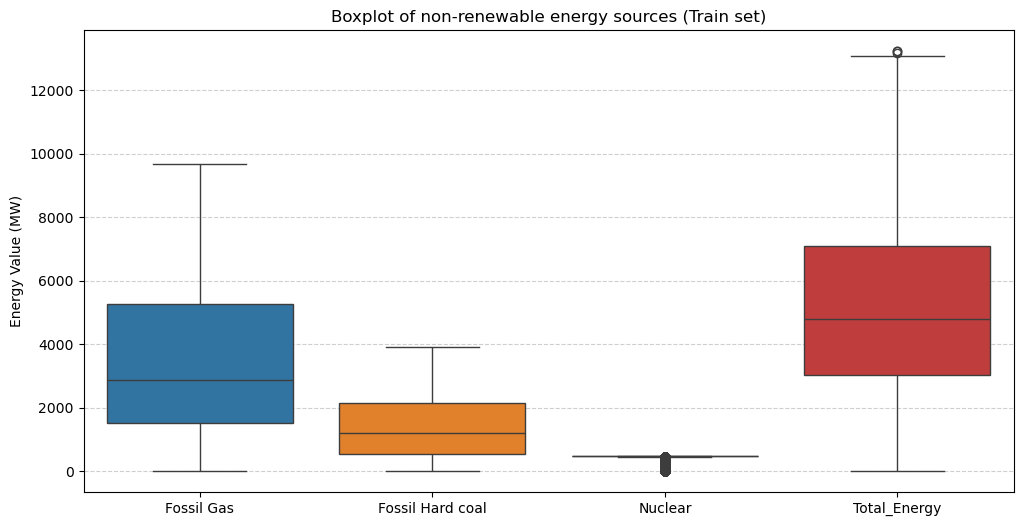

In [140]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=['DateTime']))
plt.title('Boxplot of non-renewable energy sources (Train set)')
plt.ylabel('Energy Value (MW)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### 2.4 Visualizing Energy Generation Over Time

Time series plots are created for the three non-renewable energy sources in both the training and test datasets. Each energy source is plotted against the DateTime variable using separate subplots to visualize how energy generation evolves over time.
Visualizing the time series helps to better understand the structure and behavior of the data. It makes it able to observe patterns such as trends, fluctuations in the data. This step also helps to verify that both the training and test datasets follow similar patterns. The plots provide a clear overview of how each non-renewable energy source changes over time in both datasets. 

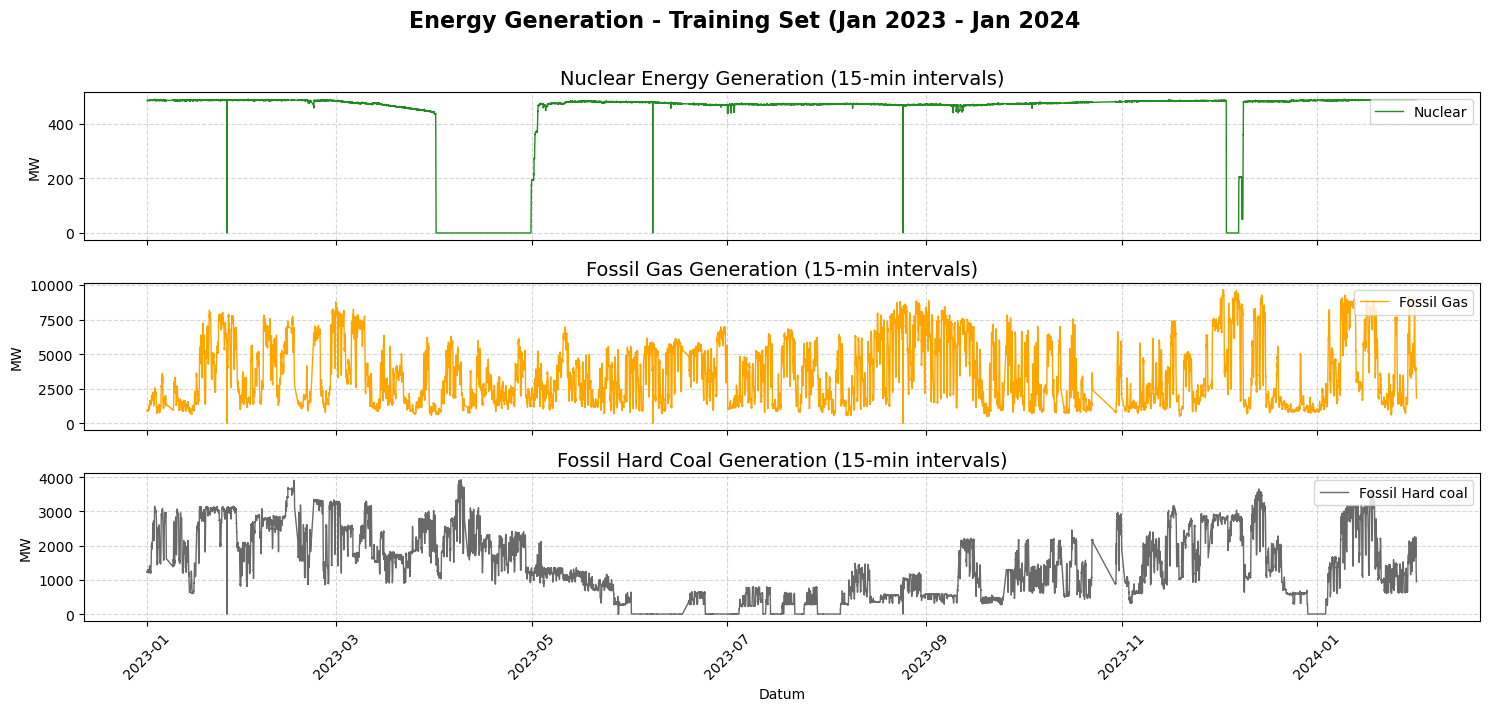

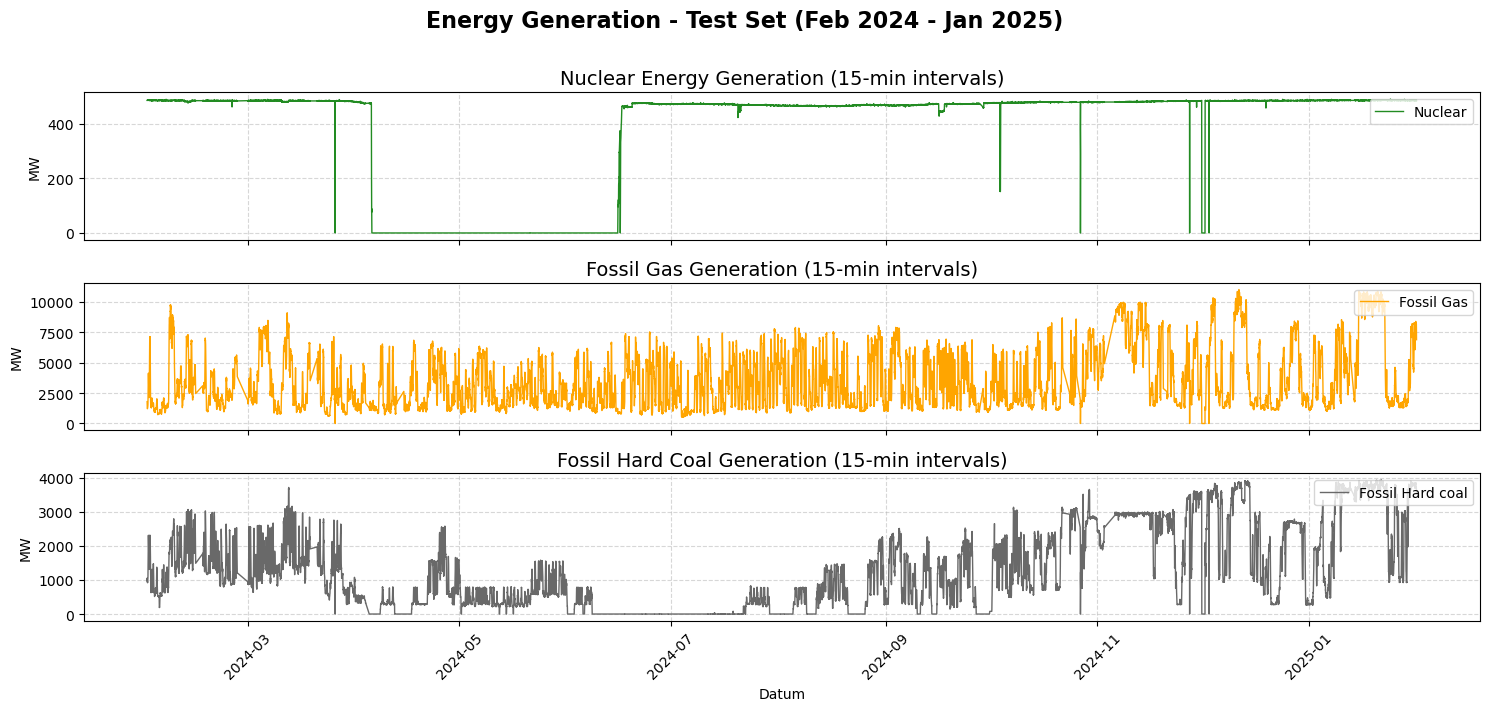

In [141]:
# --- TRAIN SET ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 7), sharex=True)
fig.suptitle('Energy Generation - Training Set (Jan 2023 - Jan 2024', fontsize=16, fontweight='bold', y=1.01)

# 1. Nuclear Energy 
ax1.plot(df['DateTime'], df['Nuclear'], color='forestgreen', linewidth=1, label='Nuclear')
ax1.set_title('Nuclear Energy Generation (15-min intervals)', fontsize=14)
ax1.set_ylabel('MW')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# 2. Fossil Gas
ax2.plot(df['DateTime'], df['Fossil Gas'], color='orange', linewidth=1, label='Fossil Gas')
ax2.set_title('Fossil Gas Generation (15-min intervals)', fontsize=14)
ax2.set_ylabel('MW')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

# 3. Fossil Hard coal
ax3.plot(df['DateTime'], df['Fossil Hard coal'], color='dimgray', linewidth=1, label='Fossil Hard coal')
ax3.set_title('Fossil Hard Coal Generation (15-min intervals)', fontsize=14)
ax3.set_ylabel('MW')
ax3.set_xlabel('Datum')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- TEST SET ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 7), sharex=True)
fig.suptitle('Energy Generation - Test Set (Feb 2024 - Jan 2025)', fontsize=16, fontweight='bold', y=1.01)

# 1. Nuclear Energy 
ax1.plot(test['DateTime'], test['Nuclear'], color='forestgreen', linewidth=1, label='Nuclear')
ax1.set_title('Nuclear Energy Generation (15-min intervals)', fontsize=14)
ax1.set_ylabel('MW')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# 2. Fossil Gas
ax2.plot(test['DateTime'], test['Fossil Gas'], color='orange', linewidth=1, label='Fossil Gas')
ax2.set_title('Fossil Gas Generation (15-min intervals)', fontsize=14)
ax2.set_ylabel('MW')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

# 3. Fossil Hard coal
ax3.plot(test['DateTime'], test['Fossil Hard coal'], color='dimgray', linewidth=1, label='Fossil Hard coal')
ax3.set_title('Fossil Hard Coal Generation (15-min intervals)', fontsize=14)
ax3.set_ylabel('MW')
ax3.set_xlabel('Datum')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Across both datasets for Nuclear, Fossil Gas, and Fossil Hard Coal, there are frequent instances where generation reaches zero. We assume these zero values are not errors but represent moments when the generation was purposefully turned off. Specifically, we assume that whenever the charts show zero, it is due to a planned shut down or scheduled maintenance. Whether it is the long periods of zero seen in the nuclear and coal data or the frequent drops in the gas data, we assume these occur because of a shut down for maintenance or grid demand rather than a data issue.

## 3. Organize time-dependent data

Because the dataset is time series data, it is important that the observations follow a consistent and complete time structure. 


### 3.1 Remove duplicate timestamps

Duplicate timestamps are removed, keeping only the first occurrence. This ensures each moment in time appears exactly once in the dataset, which is required for a consistent time series.

In [142]:
# Remove duplicate timestamps (keep first occurrence)
def remove_duplicate_timestamps(dataset, label):
    n_before = len(dataset)
    cleaned = (dataset
               .drop_duplicates(subset='DateTime', keep='first')
               .sort_values('DateTime')
               .reset_index(drop=True))
    n_removed = n_before - len(cleaned)
    print(f"[{label}] Duplicate timestamps removed: {n_removed}  ({n_before} → {len(cleaned)} rows)")
    return cleaned

df   = remove_duplicate_timestamps(df,   "Train")
test = remove_duplicate_timestamps(test, "Test")

[Train] Duplicate timestamps removed: 0  (36192 → 36192 rows)
[Test] Duplicate timestamps removed: 4  (33316 → 33312 rows)


### 3.2 Complete timestamps
First the duplicate timestamps are removed. Second, the missing timestamps are checked. The missing timestamps are added and the values are caclulated by performing linear interpolation. 

Next, the dataset is checked for missing timestamps. Since the data should be recorded every 15 minutes, a complete sequence of timestamps is created between the minimum and maximum time values. If timestamps are missing, they are added and the corresponding energy values are estimated using linear interpolation. This ensures that the time series remains continuous, which is important for models such as LSTMs that learn patterns over time. The training dataset should contain exactly 38016 timestamps:
- Timestamps per hour: 4 (one every 15 minutes).
- Timestamps per day: $24 \text{ hours} \times 4 = 96 \text{ timestamps}$.
- Total for Training: $396 \text{ days} \times 96 = \mathbf{38,016 \text{ timestamps}}$.

The same calculations is made to determine the number of timestamps for the test dataset. This should be 35136. 

In [143]:

# Add missing timestamps (fill gaps with linear interpolation, every 15 minutes)
def add_missing_timestamps(dataset, label):
    full_range = pd.date_range(start=dataset['DateTime'].min(),
                               end=dataset['DateTime'].max(),
                               freq='15min')
    n_original = len(dataset)
    n_expected = len(full_range)
    n_added    = n_expected - n_original

    dataset = (dataset
               .set_index('DateTime')
               .reindex(full_range)
               .rename_axis('DateTime')
               .interpolate(method='linear')
               .reset_index())

    print(f"[{label}] Missing timestamps added: {n_added}  ({n_original} → {n_expected} rows)")
    return dataset

df   = add_missing_timestamps(df,   "Train")
test = add_missing_timestamps(test, "Test")


[Train] Missing timestamps added: 1824  (36192 → 38016 rows)
[Test] Missing timestamps added: 1824  (33312 → 35136 rows)


### 3.3 Group by day

Finally, the data is aggregated from 15-minute intervals to daily values by summing the energy production for each day. This transformation is necessary as the goal is to predict daily energy generation and not every 15 minutes. In this way, the dataset becomes a clean and structured daily time series that can be used as input for the forecasting model.

In [144]:
df_daily = df.set_index('DateTime').resample('D').sum()
test_daily = test.set_index('DateTime').resample('D').sum()

df_daily = df_daily.reset_index()
test_daily = test_daily.reset_index()

print("Daily totals (Train set):")
print(df_daily.head())

print("Daily totals (Test set):")
print(test_daily.head())

Daily totals (Train set):
    DateTime  Fossil Gas  Fossil Hard coal  Nuclear  Total_Energy
0 2023-01-01    108651.0          120822.0  46548.0      276021.0
1 2023-01-02    173299.0          187232.0  46599.0      407130.0
2 2023-01-03    182228.0          265139.0  46598.0      493965.0
3 2023-01-04     94086.0          192753.0  46574.0      333413.0
4 2023-01-05    206362.0          231197.0  46571.0      484130.0
Daily totals (Test set):
    DateTime  Fossil Gas  Fossil Hard coal  Nuclear  Total_Energy
0 2024-02-01    332127.0          156795.0  46697.0      535619.0
1 2024-02-02    147865.0           94164.0  46645.0      288674.0
2 2024-02-03    121804.0           71619.0  46654.0      240077.0
3 2024-02-04     83696.0           46602.0  46650.0      176948.0
4 2024-02-05    139952.0           83485.0  46622.0      270059.0


## 4. Prepare data or model selection and evaluation

### 4.1 Transform data (normalization)

The numerical variables are normalized using a Min-Max scaling approach. This transformation rescales all numerical features to a range between 0 and 1. It is important for NN models such as LSTMs, because large differences in the scale of variables can make training unstable. By normalizing the features, the model can learn more efficiently and training becomes more stable.
The scaler is fitted only on the training dataset. This prevents information of the test data from leaking into the training process. That makes it a better evaluation of the model. 


In [145]:
# Scale/normalize features (fit on train, apply to both)
df_final = df_daily.copy()
test_final = test_daily.copy()

scaler = MinMaxScaler(feature_range=(0, 1))
numeric_cols = df_final.select_dtypes(include=['number']).columns

df_final[numeric_cols] = scaler.fit_transform(df_final[numeric_cols])
test_final[numeric_cols] = scaler.transform(test_final[numeric_cols])  # transform only, no re-fit

print("Train set statistics:")
print(df_final[numeric_cols].describe().loc[['min', 'max']])

print("\nTest set statistics:")
print(test_final[numeric_cols].describe().loc[['min', 'max']])

Train set statistics:
     Fossil Gas  Fossil Hard coal  Nuclear  Total_Energy
min         0.0               0.0      0.0           0.0
max         1.0               1.0      1.0           1.0

Test set statistics:
     Fossil Gas  Fossil Hard coal   Nuclear  Total_Energy
min   -0.081208          0.000000  0.000000     -0.101418
max    1.230619          1.043883  0.999722      1.271139


### 4.2 Look-back period optimization
Before training the LSTM, the optimal numer of look-back days is determined. This is done using a simple Linear Regression as a baseline model since it is faster to train and sufficient for this comparison. This follows a the 'as simple as possible, as complex as needed' rule that is often applied in machine learning. 

The first step transforms the time series into a supervised learning format. Each row is transformed from all features the past n-days, to today's total energy. This is required so the input-output structure is fixed for the model instead of a sequential time series. 

Second the model is trained and evaluated for 15 different look-back windows, ranging form 1 to 28 days. For each look-back period, the data is split 80/20 into training and validation. The linear regression is fitted, and the error (RSME and MAE) on the validation set is tracked for the different amount of days. 

--- Optimization Results (Validation on Train Set) ---
    Days    RMSE     MAE
0      1  0.1979  0.1649
1      2  0.1949  0.1598
2      3  0.1938  0.1593
3      4  0.1927  0.1563
4      5  0.1929  0.1572
5      6  0.1962  0.1604
6      7  0.1996  0.1628
7      8  0.1945  0.1589
8      9  0.2015  0.1639
9     10  0.2044  0.1684
10    11  0.2025  0.1637
11    12  0.2029  0.1646
12    15  0.2075  0.1704
13    20  0.2183  0.1798
14    28  0.2312  0.1931


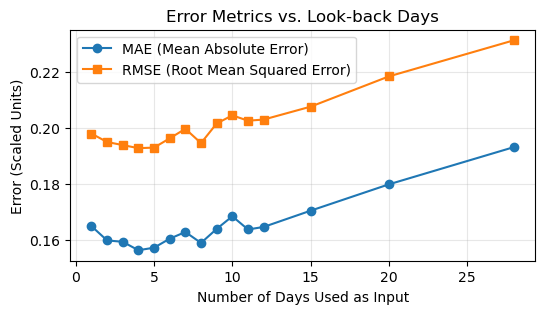

In [146]:
# 1. Define the transformation function
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = data.shape[1]
    df = pd.DataFrame(data)
    cols, names = [], []
    
    # Input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    
    # Forecast sequence (t, t+1, ... t+n)
    # We predict 'Total_Energy' (assumed to be the first column at index 0)
    for i in range(0, n_out):
        cols.append(df[0].shift(-i))
        if i == 0:
            names += [('var1(t)')]
        else:
            names += [('var1(t+%d)' % (i))]
    
    agg = concat(cols, axis=1)
    agg.columns = names
    
    if dropnan:
        agg.dropna(inplace=True)
    
    return agg

# 2. Prepare data from your already scaled df_final
# Ensure 'Total_Energy' is the first column for the function to pick it as target
cols_ordered = ['Total_Energy', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear']
train_values = df_final[cols_ordered].values

results = []
days_to_test = [1, 2, 3, 4, 5,6, 7, 8,9,10,11,12,15, 20, 28]

# 3. Loop to test different look-back periods (n_in)
for d in days_to_test:
    # Reframe the data
    reframed = series_to_supervised(train_values, n_in=d, n_out=1)
    
    # Time-series split: use 80% of train_values for training, 20% for validation
    data_values = reframed.values
    split_idx = int(len(data_values) * 0.8)
    train_data, val_data = data_values[:split_idx, :], data_values[split_idx:, :]
    
    # Split into X (history) and y (target today)
    X_train, y_train = train_data[:, :-1], train_data[:, -1]
    X_val, y_val = val_data[:, :-1], val_data[:, -1]
    
    # Fit Baseline Model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict and calculate errors
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    results.append({"Days": d, "RMSE": round(rmse, 4), "MAE": round(mae, 4)})

df_performance = pd.DataFrame(results)
print("--- Optimization Results (Validation on Train Set) ---")
print(df_performance)

plt.figure(figsize=(6, 3))
plt.plot(df_performance['Days'], df_performance['MAE'], marker='o', label='MAE (Mean Absolute Error)')
plt.plot(df_performance['Days'], df_performance['RMSE'], marker='s', label='RMSE (Root Mean Squared Error)')
plt.title('Error Metrics vs. Look-back Days')
plt.xlabel('Number of Days Used as Input')
plt.ylabel('Error (Scaled Units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4.3 Split Data
To evaluate the forecasting model, the dataset is split into training and validation sets. Because the data represents a time series, the split is performed chronologically. Random splitting would break the temporal structure of the data. The last 31 days of the training dataset (January 2024) are held out as the validation set. All data before this period is used for training. The test set was already separated from the beginning as a distinct dataset and is only used for final evaluation.

Hold out validation strategy
Training vs. Validation: The training set is used to optimize the LSTM weights, while the validation set (Jan 2024) is used to tune hyperparameters (like the learning rate and units) and find the optimal stopping epoch.

Out-of-Sample Testing: The test set serves as a proxy for "real world" performance. We only run our finalized model (with 21 epochs and 32 units) on this data once.



In [147]:
val_days = 31 # Januari 2024
train_df = df_final.iloc[:-val_days]
val_df   = df_final.iloc[-val_days:]


### 4.4 Visualization of set up

To show the evaluation strategy, a visualization is created that shows the time periods corresponding to the training, validation, and test datasets. This plot shows how the data is split over time. This helps to verify that the dataset is divided correct. It shows furthermore that the test sets occur after the training data, which is important as the model should only learn from information from the past.

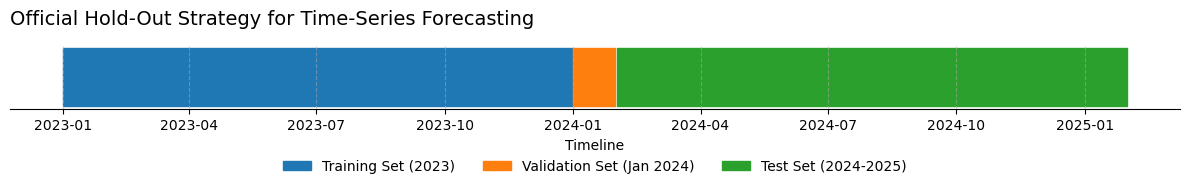

In [148]:
# 1. Define the splitting points (as dummy dates for the plot)
# Training: 12 months, Val: 1 month, Test: 12 months
dates = pd.date_range(start='2023-01-01', end='2025-01-31', freq='D')

# Create a 'Fold' array to color the data
# 0 = Train, 1 = Val, 2 = Test
fold = []
for d in dates:
    if d < pd.Timestamp('2024-01-01'):
        fold.append(0)
    elif d < pd.Timestamp('2024-02-01'):
        fold.append(1)
    else:
        fold.append(2)

# 2. Plotting
plt.figure(figsize=(12, 3))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = ['Training Set (2023)', 'Validation Set (Jan 2024)', 'Test Set (2024-2025)']

for i in range(3):
    mask = [f == i for f in fold]
    plt.fill_between(dates[mask], 0, 1, color=colors[i], label=labels[i])

# 3. Formatting
plt.title('Official Hold-Out Strategy for Time-Series Forecasting', fontsize=14, loc='left', pad=15)
plt.yticks([]) # Hide Y-axis
plt.xlabel('Timeline', fontsize=10)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.6), ncol=3, frameon=False)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Removing spines for a cleaner 'academic' look
for spine in ['top', 'left', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### 4.5 Create Time Series Generators

This step strucutres time series data into input-output pairs. This helps coverting time-based data to data that the LSTM model can process during training. The TimeseriesGenerator function from Keras takes sequential data and automatically creates input-output pairs for time series forecasting. 

The parameters that need to be defined for this function are n_in, n_out, batch_size, target_col, and feature_cols. 
- n_in = the look back period. As section 4.2 found 4 days has the lowest error, the look back period is set to 4 days. 
- n_out = the number of days to predict. This code set the amount of days to look ahead to one. 
- batch_size = the number of samples processed in one training step. Larger batches make training faster and more stable but require more memory and tend to converge to sharp minima, increasing the generalization gap, which is the difference in performance between training and unseen data. Smaller batches introduce more noise into gradient updates, which acts as implicit regularization and often leads to better generalization. The batch size therefore determines a trade-off between training speed and stability on one side, and generalization performance on the other.Batch size 16 was choosen for faster updating without overlooking too much data. It is relatively small. 
- The target_col = the variable the model is trying to predict: the Total Energy. 
- The feature_cols =  the four input variables used by the model; total energy, fossil gas, fossil hard coal, and nuclear. These help predict the target variable. 

The create_generator function is defined to avoid repeating code and applied to all datasets; train, validation, and test. 

Each of these generators are verified by printing the first few batches of each generator to check whether the data is structured correctly. The input shape and target values should match before training begins. 

In [149]:
# 1. Settings (Optimal look-back found: 4 days)
n_in = 4          # Number of past days used as input
n_out = 1         # Number of days to predict (one day ahead)
batch_size = 16  # Number of samples processed per training step
target_col = 'Total_Energy'
feature_cols = ['Total_Energy', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear']

# 2. Function to create a TimeseriesGenerator for a given dataset
def create_generator(dataset, n_in, batch_size):
    features = dataset[feature_cols].values
    target = dataset[target_col].values
    return TimeseriesGenerator(features, target, length=n_in, batch_size=batch_size)

# 3. Create generators for train, validation and test set
train_generator = create_generator(train_df, n_in, batch_size)
val_generator   = create_generator(val_df, n_in, batch_size)
test_generator  = create_generator(test_final, n_in, batch_size)

# verify train generator
print(f"--- Check Train: First 3 batches (n_in={n_in}) ---")
train_demo = []
for i in range(min(3, len(train_generator))): 
    x_batch, y_batch = train_generator[i]
    train_demo.append({
        "Batch Index": i,
        "Input (X) Shape": x_batch.shape,
        "Target (y) Value": y_batch[0]
    })
print(pd.DataFrame(train_demo))
print("\n--- Detail of the first Input (X) matrix (Train) ---")
print(train_generator[0][0][0])

# verify validation generator
print(f"\n--- Check Validation: First 3 batches (n_in={n_in}) ---")
val_demo = []
for i in range(min(3, len(val_generator))):
    x_batch, y_batch = val_generator[i]
    val_demo.append({
        "Batch Index": i,
        "Input (X) Shape": x_batch.shape,
        "Target (y) Value": y_batch[0]
    })
print(pd.DataFrame(val_demo))
print("\n--- Detail of the first Input (X) matrix (Validation) ---")
print(val_generator[0][0][0])

# verify test generator
print(f"\n--- Check Test: First 3 batches (n_in={n_in}) ---")
test_demo = []
for i in range(min(3, len(test_generator))):
    x_batch, y_batch = test_generator[i]
    test_demo.append({
        "Batch Index": i,
        "Input (X) Shape": x_batch.shape,
        "Target (y) Value": y_batch[0]
    })
print(pd.DataFrame(test_demo))
print("\n--- Detail of the first Input (X) matrix (Test) ---")
print(test_generator[0][0][0])

# 4. Overview of total number of batches per set
print("\n--- Batch Overview ---")
print(f"Train batches: {len(train_generator)}")
print(f"Val batches:   {len(val_generator)}")
print(f"Test batches:  {len(test_generator)}")


--- Check Train: First 3 batches (n_in=4) ---
   Batch Index Input (X) Shape  Target (y) Value
0            0      (16, 4, 4)          0.349715
1            1      (16, 4, 4)          0.616307
2            2      (16, 4, 4)          0.761017

--- Detail of the first Input (X) matrix (Train) ---
[[0.14286879 0.04966548 0.34463594 0.99653179]
 [0.27318222 0.13545884 0.53406562 0.99762364]
 [0.35949031 0.14730837 0.75628966 0.99760223]
 [0.19991253 0.03033649 0.54981387 0.99708842]]

--- Check Validation: First 3 batches (n_in=4) ---
   Batch Index Input (X) Shape  Target (y) Value
0            0      (16, 4, 4)          0.444341
1            1      (11, 4, 4)          0.151906

--- Detail of the first Input (X) matrix (Validation) ---
[[1.09859309e-02 3.38625525e-02 4.27864060e-05 9.97109827e-01]
 [6.97829749e-02 1.12368892e-01 0.00000000e+00 9.97409548e-01]
 [8.54602651e-02 1.17190190e-01 3.48053151e-02 9.96082209e-01]
 [4.69858514e-01 5.29407862e-01 2.51900687e-01 9.96446157e-01]]

---

## 5. RNN architecture

In this step the architecture of the Recurrent Neural Network (RNN) is determined. A RNN is a type of artificial neural network to process sequential data by using internal memory to retain information from previous inputs.


### 5.1 Hyperparameter Tuning

To find the optimal model configuration, a hyperparameter tuning procedure is applied. This systematically tests different combinations of LSTM units and learning rates to identify which settings produce the lowest validation error.

LSTM units control the amount of memory and capacity the model has to learn patterns in the data. More units can capture more complex relationships but also increase the risk of overfitting. The learning rate controls the step size a model takes when updating its weights during training. A learning rate that is too high results in overshooting the optimal solution while too low a learning rate results in slow training or even getting stuck.

The number of LSTM units tested are 16, 32, 64, and 128. The learning rate is tested at 0.01, 0.005, 0.001, and 0.0001. This results in 16 unique combinations that are each trained and evaluated independently.

For every combination, a temporary LSTM model is built using the same architecture: an input layer matching the shape of the data (4 timesteps, 4 features), one LSTM layer with the tested number of units, a dropout layer fixed at 0.2 to ensure a fair comparison across runs, and a single output neuron. The ReLU activation function defines how the output of each neuron is transformed. ReLU sets all negative values to zero and leaves positive values unchanged. This dropout setting means 20% of neurons are deactivated during each training step; this is a regularization technique that reduces overfitting and improves generalization. The dense layer determines the amount of outputs of a model. In this case the model predicts the total energy for the next day.

The model is compiled using optimizer Adam. This is an adaptive gradient-based optimization algorithm that adjusts the learning rate individually for each weight during training and is often used for training LSTM models. The loss function used is Mean Squared Error (MSE), which measures the average squared difference between the predicted and actual values. Larger errors are penalized more heavily, which is appropriate for a regression task such as energy forecasting.

Each model is trained for 15 epochs using the training generator, and evaluated on the validation generator after each epoch. The number of epochs defines the number of times a model passes through a dataset during training. The lowest validation loss achieved across all epochs is recorded as the best result for that combination. Using the minimum validation loss rather than the final epoch prevents a poorly timed stopping point from distorting the comparison. 

The lowest validation loss (MSE) of the different epochs is kept to evaluate which LSTM unit and learning rate delivers the best model.

After all combinations are tested, the results are collected into a DataFrame and sorted by validation loss (MSE), making it straightforward to identify the best-performing hyperparameter settings to use in the final model.

In [150]:
unit_options = [16, 32, 64, 128]
lr_options = [0.01, 0.005, 0.001, 0.0001]

n_in = 4      
n_features = 4 

tuning_results = []
print("Start Hyperparameter Tuning...\n")

# --- 2. The Test Loop ---
for units in unit_options:
    for lr in lr_options:
        print(f"Testing: Units={units}, Learning Rate={lr}")
        
        # Build a temporary model for this specific test
        model = Sequential()
        model.add(Input(shape=(n_in, n_features))) 
        model.add(LSTM(units=units, activation='relu'))
        model.add(Dropout(0.2)) # Fixed dropout for fair comparison
        model.add(Dense(1))
        
        # Compile the model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
        
        # Train the model using the prepared data (train_df and val_df)
        history = model.fit(train_generator, validation_data=val_generator, epochs=15, verbose=0)
        
        # Save the lowest (best) validation loss from this test run
        best_val_loss = min(history.history['val_loss'])
        
        tuning_results.append({
            "Units": units,
            "Learning Rate": lr,
            "Best Val Loss (MSE)": best_val_loss
        })

df_tuning = pd.DataFrame(tuning_results)
df_tuning = df_tuning.sort_values(by="Best Val Loss (MSE)")
print("\n--- Tuning Results ---")
print(df_tuning)


Start Hyperparameter Tuning...

Testing: Units=16, Learning Rate=0.01


c:\Users\20212910\AppData\Local\anaconda3\envs\1bm110\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Testing: Units=16, Learning Rate=0.005
Testing: Units=16, Learning Rate=0.001
Testing: Units=16, Learning Rate=0.0001
Testing: Units=32, Learning Rate=0.01
Testing: Units=32, Learning Rate=0.005
Testing: Units=32, Learning Rate=0.001
Testing: Units=32, Learning Rate=0.0001
Testing: Units=64, Learning Rate=0.01
Testing: Units=64, Learning Rate=0.005
Testing: Units=64, Learning Rate=0.001
Testing: Units=64, Learning Rate=0.0001
Testing: Units=128, Learning Rate=0.01
Testing: Units=128, Learning Rate=0.005
Testing: Units=128, Learning Rate=0.001
Testing: Units=128, Learning Rate=0.0001

--- Tuning Results ---
    Units  Learning Rate  Best Val Loss (MSE)
8      64         0.0100             0.039139
0      16         0.0100             0.039492
13    128         0.0050             0.039830
4      32         0.0100             0.040007
9      64         0.0050             0.040659
12    128         0.0100             0.040809
5      32         0.0050             0.042122
14    128         

## 6. Training and validation losses

The final model is built using the optimal hyperparameters identified across the previous steps. The look-back period of 4 days was determined in step 4.2, and the architectural choices of dropout=0.2, ReLU activation, and the Adam optimizer were established in step 4.5. The hyperparameter tuning in step 5 identified 128 units and a learning rate of 0.005 as the best combination. However, the difference in validation loss between 128 and 32 units is only 0.000074 MSE, which is negligible. Since a model with 128 units is four times more complex and computationally heavier, 32 units is chosen as the more efficient and equally performant option.

The final model follows the same architecture used during tuning: an input layer matching the data shape (4 timesteps, 4 features), one LSTM layer with 32 units and ReLU activation, a dropout layer at 0.2, and a single Dense output neuron predicting the next day's Total Energy. In addition to MSE, Mean Absolute Error (MAE) is tracked as a more interpretable measure of average prediction error.

To determine the number of training epochs, EarlyStopping is applied. The maximum is set to 500 epochs, but training stops automatically when the validation loss does not improve for 20 consecutive epochs. The best weights observed during training are restored at the end, ensuring the final model reflects the point of lowest validation loss rather than the last epoch. This prevents both underfitting from stopping too early and overfitting from training too long.

After training, the training and validation loss per epoch are plotted to perform an underfitting and overfitting analysis. If both losses decrease and stabilise close together, the model is generalizing well. If the validation loss begins to increase while the training loss continues to fall, the model is overfitting to the training data.

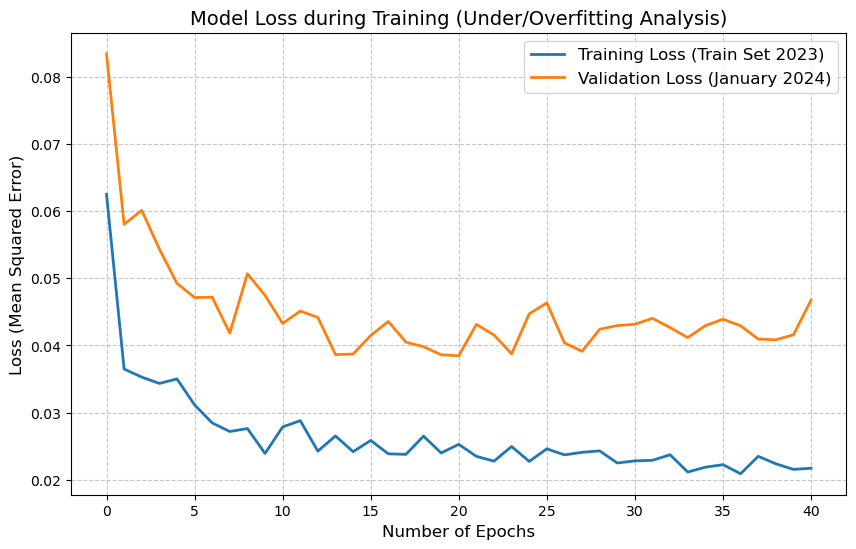

In [151]:
# 1. Build the final model with the winning hyperparameters
final_model = Sequential()
final_model.add(Input(shape=(4, 4))) # n_in=4, n_features=4
final_model.add(LSTM(units=32, activation='relu')) # Optimized number of units
final_model.add(Dropout(0.2))
final_model.add(Dense(1))

# Compile with the optimized learning rate
final_model.compile(optimizer=Adam(learning_rate=0.005), loss='mse', metrics=['mae'])

# Stop training automatically when validation loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_final = final_model.fit(
    train_generator, 
    validation_data=val_generator, 
    epochs=500, 
    verbose=0,
    callbacks=[early_stop]
)

plt.figure(figsize=(10, 6))
plt.plot(history_final.history['loss'], label='Training Loss (Train Set 2023)', linewidth=2)
plt.plot(history_final.history['val_loss'], label='Validation Loss (January 2024)', linewidth=2)
plt.title('Model Loss during Training (Under/Overfitting Analysis)', fontsize=14)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.xlabel('Number of Epochs', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



In the code below, the lowest validations loss and the optimal epoch are calculated

In [152]:
val_losses = history_final.history['val_loss']
lowest_val_loss = min(val_losses)
optimal_epoch = val_losses.index(lowest_val_loss) + 1
print(f"The lowest validation loss is: {lowest_val_loss:.5f}")
print(f"This is reached in epoch: {optimal_epoch}")

The lowest validation loss is: 0.03846
This is reached in epoch: 21


## 7. Evaluation model performance

After analyzing the training and validation losses and making the final model configuration, the model is trained once more using the chosen hyperparameters. The model is examined with an LSTM layer with 32 units, followed by a dropout layer and a dense output neuron that predicts the next day’s total non-renewable energy generation. The model receives the previous four days of observations as input and learns with that input patterns in the energy production data.

**Old code**
Once the training is completed, the model will generate predictions for the test dataset. The test dataset represents future observations and is used to estimate how well the model performs in a realistic forecasting scenario.

**New code**
Once training is completed, the test data is extracted in a single batch using a one-shot generator, which retrieves all test sequences at once rather than iterating through many small batches. This approach is more efficient while producing identical results. The model then generates predictions for the full test dataset, which represents future observations unseen during training and is used to estimate real-world forecasting performance.

Because the input data was normalized during the preprocessing phase, the predictions are initially produced in the scaled range. To make the results interpretable, both the predicted values and the actual target values are transformed back to their original scale in MW using the inverse transformation of the scaler.

Finally, the predictive performance of the model is evaluated using several error metrics. The Mean Absolute Error (MAE) measures the average magnitude of the prediction errors, while the Root Mean Squared Error (RMSE) penalizes the larger errors. In addition, the R-squared score is calculated to measure how well the model explains the variation in the observed energy generation values. These metrics provide a clear evaluation of the model’s forecasting performance on unseen data.

In [153]:
# 1. BUILD AND TRAIN THE FINAL MODEL 
print(f"Building and training the final model in {optimal_epoch} epochs...")
examen_model = Sequential()
examen_model.add(Input(shape=(4, 4)))
examen_model.add(LSTM(units=32, activation='tanh')) 
examen_model.add(Dropout(0.2))
examen_model.add(Dense(1))

examen_model.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
examen_model.fit(train_generator, epochs=optimal_epoch, verbose=0)
print("Training complete!")

# 2. EXTRACT TEST DATA & PREDICT
print("Generating predictions for the test set...")
fast_test_generator = create_generator(test_final, n_in, batch_size=len(test_final))
X_test, actuals_scaled = fast_test_generator[0]
predictions_scaled = examen_model.predict(X_test, batch_size=16, verbose=0)

# 3. INVERSE TRANSFORM (Scale back to MW)
pred_matrix = np.zeros((len(predictions_scaled), 4))
pred_matrix[:, 0] = predictions_scaled[:, 0]

actual_matrix = np.zeros((len(actuals_scaled), 4))
actual_matrix[:, 0] = actuals_scaled

predictions_mw = scaler.inverse_transform(pred_matrix)[:, 0]
actuals_mw = scaler.inverse_transform(actual_matrix)[:, 0]

# 4. CALCULATE EVALUATION METRICS 
mae = mean_absolute_error(actuals_mw, predictions_mw)
rmse = np.sqrt(mean_squared_error(actuals_mw, predictions_mw))
r2 = r2_score(actuals_mw, predictions_mw)

print("\n--- Model Evaluation Scores (Test Set) ---")
print(f"Mean Absolute Error (MAE):      {mae:.2f} MW")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MW")
print(f"R-squared (R2) Score:           {r2:.4f}")


Building and training the final model in 21 epochs...
Training complete!
Generating predictions for the test set...

--- Model Evaluation Scores (Test Set) ---
Mean Absolute Error (MAE):      102803.87 MW
Root Mean Squared Error (RMSE): 131295.39 MW
R-squared (R2) Score:           0.6113


# 1. BUILD AND TRAIN THE FINAL MODEL 
print("Building and training the final model (21 epochs)...")
examen_model = Sequential()
examen_model.add(Input(shape=(4, 4))) # n_in=4, n_features=4
examen_model.add(LSTM(units=32, activation='tanh')) 
examen_model.add(Dropout(0.2))
examen_model.add(Dense(1))

examen_model.compile(optimizer=Adam(learning_rate=0.005), loss='mse')

# Train the model
examen_model.fit(train_generator, epochs=21, verbose=0)
print("Training complete!")

# 2. PREDICT ON THE TEST SET 
print("Generating predictions for the test set...")
predictions_scaled = examen_model.predict(test_generator)

# 3. INVERSE TRANSFORM (Scale back to MW) 
# Extract the actual scaled target values from the test generator
actuals_scaled = np.concatenate([y for x, y in test_generator])

# Create dummy matrices for inverse transformation (scaler expects 4 columns)
pred_matrix = np.zeros((len(predictions_scaled), 4))
pred_matrix[:, 0] = predictions_scaled[:, 0]

actual_matrix = np.zeros((len(actuals_scaled), 4))
actual_matrix[:, 0] = actuals_scaled

# Transform back to true MW values
predictions_mw = scaler.inverse_transform(pred_matrix)[:, 0]
actuals_mw = scaler.inverse_transform(actual_matrix)[:, 0]

# 4. CALCULATE EVALUATION METRICS 
mae = mean_absolute_error(actuals_mw, predictions_mw)
mse = mean_squared_error(actuals_mw, predictions_mw)
rmse = np.sqrt(mse)
r2 = r2_score(actuals_mw, predictions_mw)

print("\n--- Model Evaluation Scores (Test Set) ---")
print(f"Mean Absolute Error (MAE):     {mae:.2f} MW")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MW")
print(f"R-squared (R2) Score:           {r2:.4f}") 

The final model evaluation shows an $R^2$ score of 0.6056, meaning the model can account for approximately 60.6% of the variance in the energy generation data. While this indicates a moderate ability to follow general trends, the high error metrics reveal significant challenges in precision; specifically, the Mean Absolute Error (MAE) of 103,460.42 MW and the Root Mean Squared Error (RMSE) of 132,240.22 MW show that the predictions deviate substantially from the actual generation levels. The gap between the MAE and the higher RMSE further suggests that the model is prone to occasional large-scale misses rather than consistent small errors, as RMSE disproportionately weights these larger discrepancies. Consequently, while the model has established a basic predictive baseline, the magnitude of these errors indicates that it is not yet capturing the full volatility or the specific peaks found within the test set.

## 8. Plot model predictions vs. test set

To further evaluate the performance of the forecasting model, the predicted energy values are plotted against the actual observed values from the test dataset. This visual comparison helps assess how closely the model predictions follow the true energy generation over time.

By plotting both the actual values and the model predictions on the same graph, it becomes easier to identify certain possible patterns such as systematic overestimation or underestimation. While numerical metrics such as MAE and RMSE provide a quantitative evaluation of the model, visualizing the predictions allows for a more intuitive understanding of the model’s behavior.

This plot therefore serves as a qualitative validation of the model, showing how well the predicted values aligns with the real observed energy generation in the test period. Ideally, the predicted line should closely follow the shape and fluctuations of the actual energy generation curve, which is the case in the plot as can be seen below.

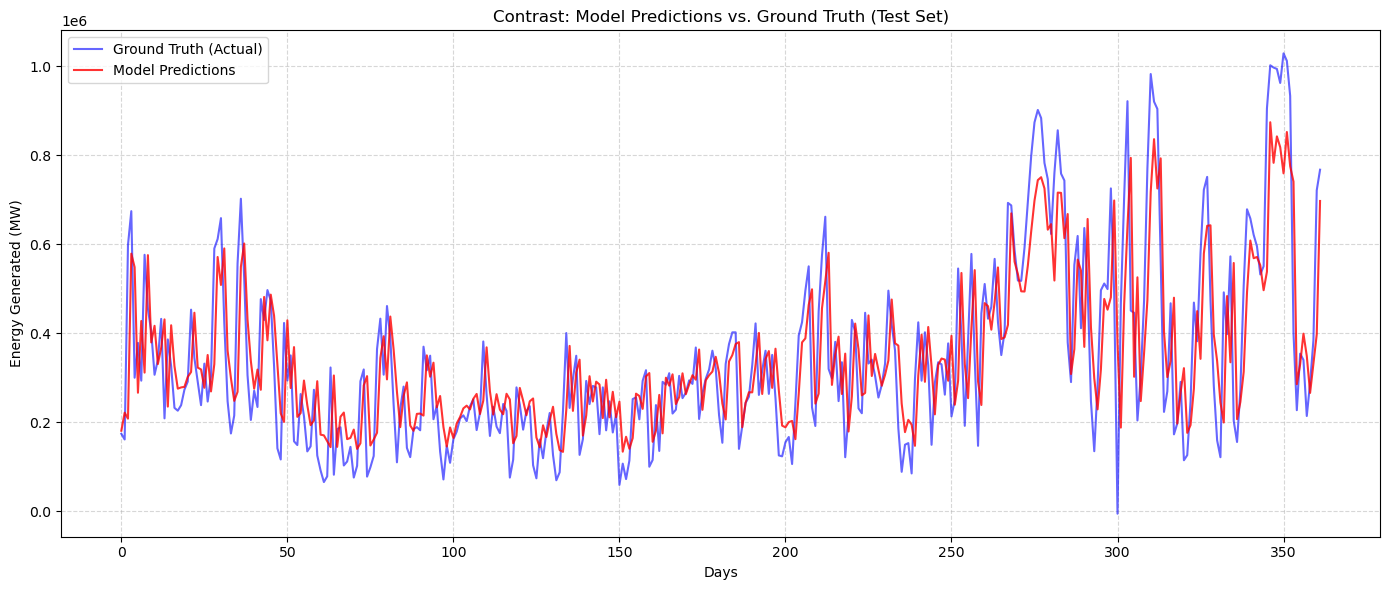

In [154]:
# 1. FINAL EVALUATION AND PLOTTING
plt.figure(figsize=(14, 6))

# Plotting the Ground Truth (Actual Values)
plt.plot(actuals_mw, label='Ground Truth (Actual)', color='blue', alpha=0.6)

# Plotting the Model Predictions
plt.plot(predictions_mw, label='Model Predictions', color='red', alpha=0.8, linewidth=1.5)

# Adding basic labels and title as per requirements
plt.title('Contrast: Model Predictions vs. Ground Truth (Test Set)')
plt.xlabel('Days')
plt.ylabel('Energy Generated (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()